<a href="https://colab.research.google.com/github/SuryaPrasad2527/Deep-Learning-/blob/main/Expp02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task A: Visualization of Activation Functions

In [ ]:
#Surya Prasad M
#24BAD119

import numpy as np
import matplotlib.pyplot as plt

# Input values
x = np.linspace(-10, 10, 500)

# Activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

# Calculate outputs
y_sigmoid = sigmoid(x)
y_tanh = tanh(x)
y_relu = relu(x)

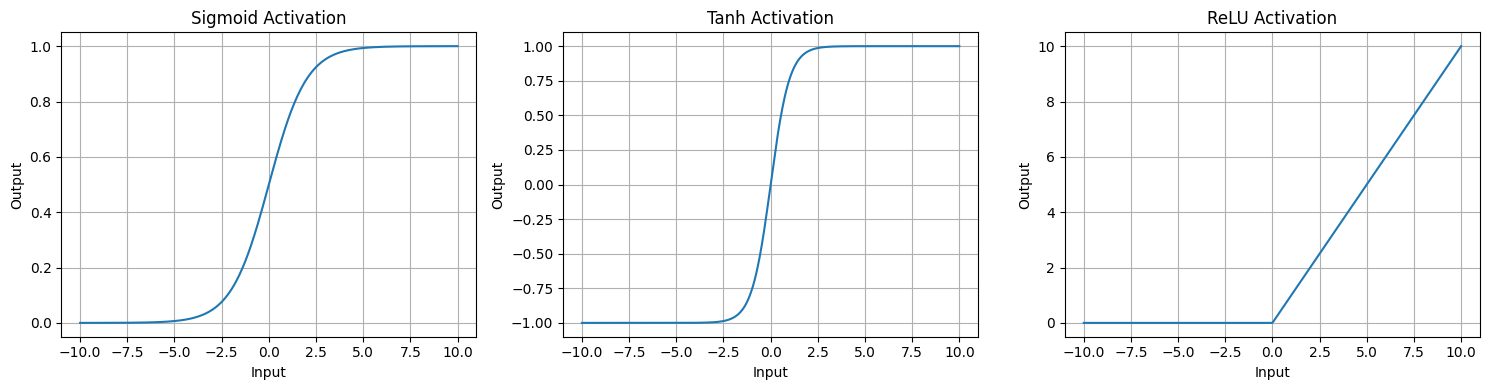

In [ ]:
plt.figure(figsize=(15, 4))

# Sigmoid
plt.subplot(1, 3, 1)
plt.plot(x, y_sigmoid)
plt.title("Sigmoid Activation")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)

# Tanh
plt.subplot(1, 3, 2)
plt.plot(x, y_tanh)
plt.title("Tanh Activation")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)

# ReLU
plt.subplot(1, 3, 3)
plt.plot(x, y_relu)
plt.title("ReLU Activation")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
print("ACTIVATION FUNCTION COMPARISON")
print("-" * 75)

print("Sigmoid : Range = (0,1), Saturates at extremes, Computationally moderate")
print("Tanh    : Range = (-1,1), Saturates at extremes, Computationally moderate")
print("ReLU    : Range = [0,∞), No saturation for positive values, Computationally efficient")

ACTIVATION FUNCTION COMPARISON
---------------------------------------------------------------------------
Sigmoid : Range = (0,1), Saturates at extremes, Computationally moderate
Tanh    : Range = (-1,1), Saturates at extremes, Computationally moderate
ReLU    : Range = [0,∞), No saturation for positive values, Computationally efficient


Task B: Performance Comparison of Activation Functions

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data: (60000, 28, 28)
Testing data: (10000, 28, 28)


In [ ]:
def create_model(activation):

    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation=activation),
        Dense(64, activation=activation),
        Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
activations = ["sigmoid", "tanh", "relu"]
histories = {}
results = {}

for activation in activations:

    print("\nTraining with:", activation)

    model = create_model(activation)

    history = model.fit(
        x_train,
        y_train,
        validation_split=0.2,
        epochs=15,
        batch_size=128,
        verbose=1
    )

    histories[activation] = history

    results[activation] = {
        "Training Accuracy": history.history["accuracy"][-1],
        "Validation Accuracy": history.history["val_accuracy"][-1],
        "Training Loss": history.history["loss"][-1],
        "Validation Loss": history.history["val_loss"][-1]
    }


Training with: sigmoid


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7919 - loss: 0.9077 - val_accuracy: 0.9102 - val_loss: 0.3535
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9168 - loss: 0.3042 - val_accuracy: 0.9328 - val_loss: 0.2428
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9354 - loss: 0.2286 - val_accuracy: 0.9423 - val_loss: 0.2024
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9464 - loss: 0.1860 - val_accuracy: 0.9513 - val_loss: 0.1707
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9553 - loss: 0.1545 - val_accuracy: 0.9582 - val_loss: 0.1506
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9623 - loss: 0.1308 - val_accuracy: 0.9612 - val_loss: 0.1351
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9678 - loss: 0.1118 - val_accuracy: 0.9656 - val_loss: 0.1224
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9727 - loss: 0.0963 - val_accuracy: 

In [ ]:
print("\nACTIVATION FUNCTION RESULTS")
print("=" * 90)

for activation, result in results.items():

    print("\nActivation:", activation)
    print("Training Accuracy :", round(result["Training Accuracy"], 4))
    print("Validation Accuracy:", round(result["Validation Accuracy"], 4))
    print("Training Loss     :", round(result["Training Loss"], 4))
    print("Validation Loss   :", round(result["Validation Loss"], 4))


ACTIVATION FUNCTION RESULTS

Activation: sigmoid
Training Accuracy : 0.9904
Validation Accuracy: 0.9754
Training Loss     : 0.0372
Validation Loss   : 0.0858

Activation: tanh
Training Accuracy : 0.9986
Validation Accuracy: 0.9762
Training Loss     : 0.0074
Validation Loss   : 0.0954

Activation: relu
Training Accuracy : 0.9972
Validation Accuracy: 0.9736
Training Loss     : 0.0099
Validation Loss   : 0.1113


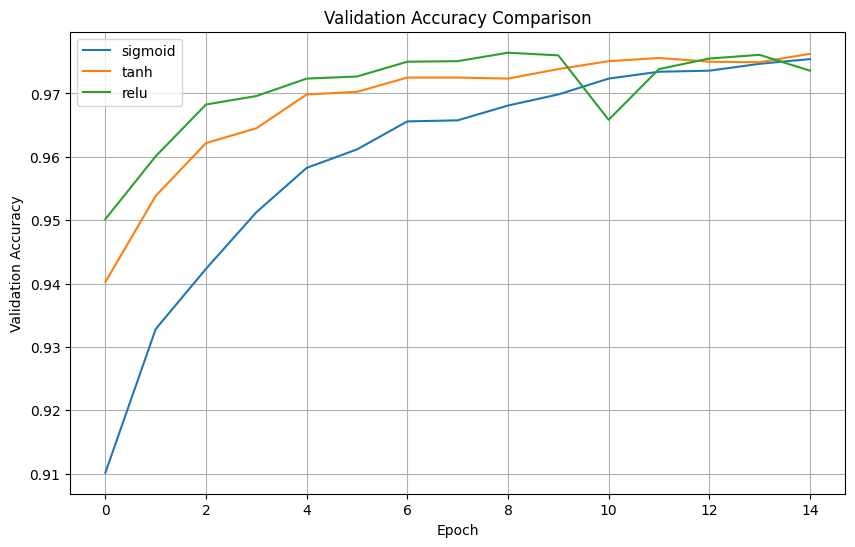

In [ ]:
plt.figure(figsize=(10, 6))

for activation in activations:
    plt.plot(
        histories[activation].history["val_accuracy"],
        label=activation
    )

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

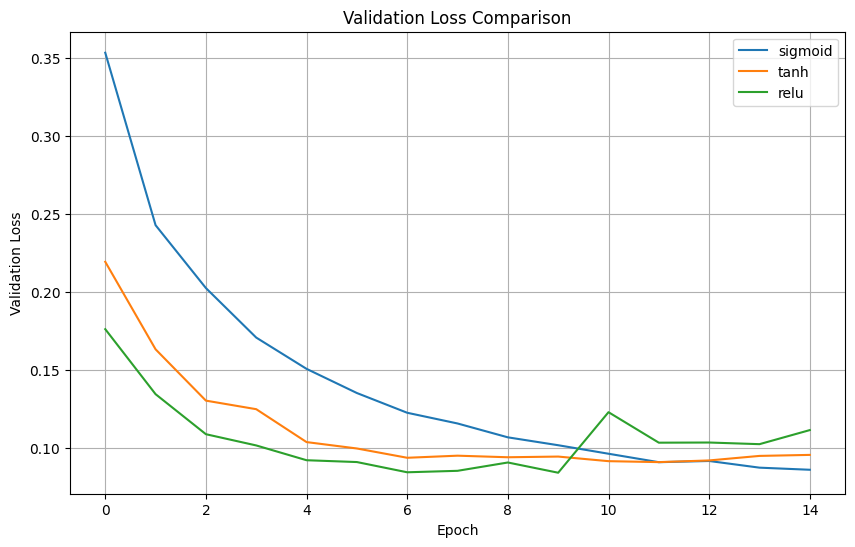

In [ ]:
plt.figure(figsize=(10, 6))

for activation in activations:
    plt.plot(
        histories[activation].history["val_loss"],
        label=activation
    )

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

Task C: Comparison of Optimization Algorithms

In [ ]:
from tensorflow.keras.optimizers import SGD, RMSprop, Adam

optimizers = {
    "SGD": SGD(learning_rate=0.01),

    "Momentum": SGD(
        learning_rate=0.01,
        momentum=0.9
    ),

    "RMSProp": RMSprop(
        learning_rate=0.001
    ),

    "Adam": Adam(
        learning_rate=0.001
    )
}

In [ ]:
def create_optimizer_model(optimizer):

    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation="relu"),
        Dense(64, activation="relu"),
        Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
optimizer_histories = {}
optimizer_results = {}

for name, optimizer in optimizers.items():

    print("\nTraining with:", name)

    model = create_optimizer_model(optimizer)

    history = model.fit(
        x_train,
        y_train,
        validation_split=0.2,
        epochs=15,
        batch_size=128,
        verbose=1
    )

    optimizer_histories[name] = history

    optimizer_results[name] = {
        "Training Accuracy": history.history["accuracy"][-1],
        "Validation Accuracy": history.history["val_accuracy"][-1],
        "Training Loss": history.history["loss"][-1],
        "Validation Loss": history.history["val_loss"][-1]
    }


Training with: SGD
Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6506 - loss: 1.3844 - val_accuracy: 0.8462 - val_loss: 0.7104
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8566 - loss: 0.5781 - val_accuracy: 0.8842 - val_loss: 0.4482
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8841 - loss: 0.4315 - val_accuracy: 0.8995 - val_loss: 0.3716
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8956 - loss: 0.3739 - val_accuracy: 0.9087 - val_loss: 0.3326
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9031 - loss: 0.3412 - val_accuracy: 0.9133 - val_loss: 0.3095
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9096 - loss: 0.3184 - val_accuracy: 0.9184 - val_loss: 0.2924
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9144 - loss: 0.3009 - val_accuracy: 0.9226 - val_loss: 0.2778
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9185 - loss: 0.286

In [ ]:
print("\nOPTIMIZER COMPARISON")
print("=" * 90)

for name, result in optimizer_results.items():

    print("\nOptimizer:", name)
    print("Training Accuracy :", round(result["Training Accuracy"], 4))
    print("Validation Accuracy:", round(result["Validation Accuracy"], 4))
    print("Training Loss     :", round(result["Training Loss"], 4))
    print("Validation Loss   :", round(result["Validation Loss"], 4))


OPTIMIZER COMPARISON

Optimizer: SGD
Training Accuracy : 0.9373
Validation Accuracy: 0.9407
Training Loss     : 0.2197
Validation Loss   : 0.2134

Optimizer: Momentum
Training Accuracy : 0.9897
Validation Accuracy: 0.9746
Training Loss     : 0.0368
Validation Loss   : 0.0875

Optimizer: RMSProp
Training Accuracy : 0.9971
Validation Accuracy: 0.9747
Training Loss     : 0.0093
Validation Loss   : 0.1156

Optimizer: Adam
Training Accuracy : 0.9965
Validation Accuracy: 0.974
Training Loss     : 0.011
Validation Loss   : 0.1113


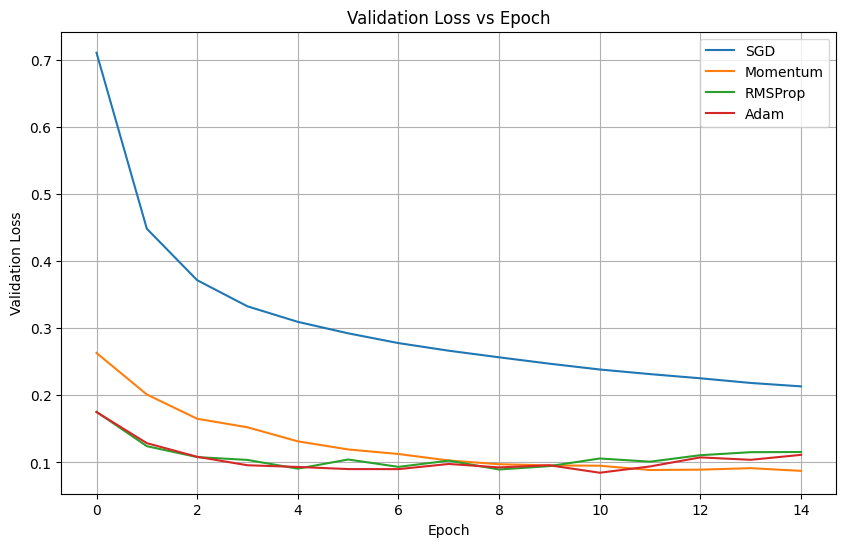

In [ ]:
plt.figure(figsize=(10, 6))

for name in optimizers:

    plt.plot(
        optimizer_histories[name].history["val_loss"],
        label=name
    )

plt.title("Validation Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

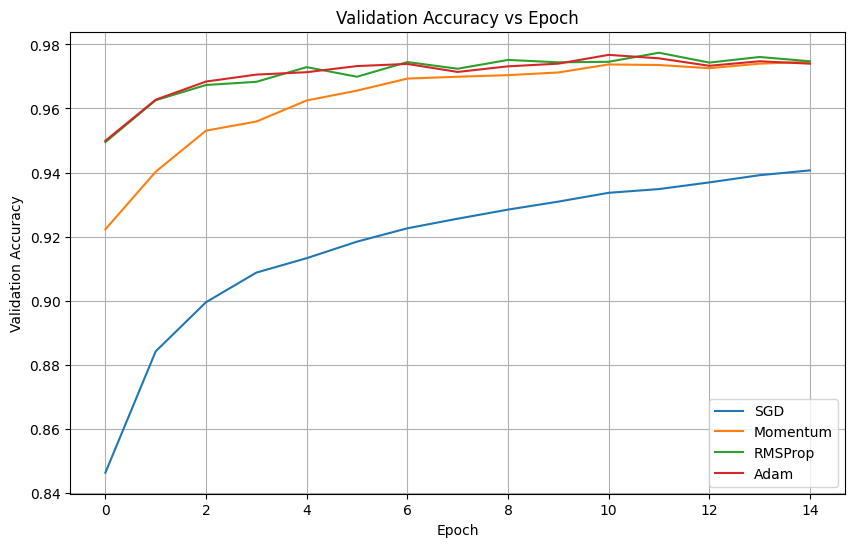

In [ ]:
plt.figure(figsize=(10, 6))

for name in optimizers:

    plt.plot(
        optimizer_histories[name].history["val_accuracy"],
        label=name
    )

plt.title("Validation Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Task D: Deep Learning Experiment Management

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

project_path = "/content/drive/MyDrive/DL_Experiment"

os.makedirs(project_path, exist_ok=True)

print("Project folder created:")
print(project_path)

Project folder created:
/content/drive/MyDrive/DL_Experiment


In [ ]:
model.save(
    "/content/drive/MyDrive/DL_Experiment/cnn_model.keras"
)

print("Model saved successfully.")

Model saved successfully.


In [ ]:
import pandas as pd

results_df = pd.DataFrame(optimizer_results).T

results_df.to_csv(
    "/content/drive/MyDrive/DL_Experiment/optimizer_results.csv"
)

print("Results saved successfully.")

Results saved successfully.


In [ ]:
!git config --global user.name "SuryaPrasad2527"
!git config --global user.email "suryaprasad0027@gmail.com"

In [ ]:
!git clone https://github.com/SuryaPrasad2527/Deep-Learning-

Cloning into 'Deep-Learning-'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (7/7), done.
Receiving objects: 100% (9/9), 8.09 KiB | 8.09 MiB/s, done.
remote: Total 9 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)


In [ ]:
!cp "/content/drive/MyDrive/DL_Experiment/optimizer_results.csv" \
"/content/Deep-Learning-"

In [ ]:
%cd /content/Deep-Learning-

!git add .
!git commit -m "Added activation function and optimizer experiments"

/content/Deep-Learning-
hint: You've added another git repository inside your current repository.
hint: Clones of the outer repository will not contain the contents of
hint: the embedded repository and will not know how to obtain it.
hint: If you meant to add a submodule, use:
hint: 
hint: 	git submodule add <url> Deep-Learning-
hint: 
hint: If you added this path by mistake, you can remove it from the
hint: index with:
hint: 
hint: 	git rm --cached Deep-Learning-
hint: 
hint: See "git help submodule" for more information.
[main 92049a0] Added activation function and optimizer experiments
 1 file changed, 1 insertion(+)
 create mode 160000 Deep-Learning-


In [ ]:
!git remote -v

origin	https://github.com/SuryaPrasad2527/Deep-Learning- (fetch)
origin	https://github.com/SuryaPrasad2527/Deep-Learning- (push)


In [ ]:
%cd /content/Deep-Learning-

!git remote set-url origin https://github.com/SuryaPrasad2527/Deep-Learning-
!git config --global credential.helper store
!git push origin main

/content/Deep-Learning-
92049a0 (HEAD -> main) Added activation function and optimizer experiments
9c6115e Added activation function and optimizer experiments
bda0ea3 (origin/main, origin/HEAD) Add files via upload
fatal: could not read Username for 'https://github.com': No such device or address


In [ ]:
!git push origin main

fatal: could not read Username for 'https://github.com': No such device or address
